Evaluacion 1 

In [104]:
from __future__ import print_function, division

%matplotlib inline

import thinkdsp
import thinkplot
import thinkstats2
import random
import numpy as np
import pandas as pd

from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')
import math

1.La señal “cuadrada.wav”, que contiene una señal cuadrada, fue muestreada a 11025 muestras/s. Establezca la frecuencia fundamental de la señal, considerando que es posible que la velocidad de muestreo genere aliasing. Reconstruya la señal filtrando las componentes - si es posible - para que no ocurra aliasing, en ese caso.

Solución:

Primero, se carga el archivo cuadrada.wav

In [105]:
wave = thinkdsp.read_wave('cuadrada.wav')
wave.normalize()
wave.make_audio()


Podemos observar el espectro, dado que la señal es del tipo cuadrada, deveria tener solo las componentes impares, por lo que se puede observar que por la cantidad de muestras, esta presenta aliasing

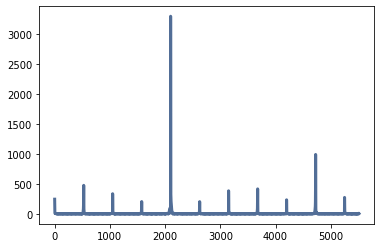

In [106]:
spectrum = wave.make_spectrum()
spectrum.plot()

La señal parece tener una frequencia de 2100Hz, para verificar esto, construimos otra señal cuadrada con esta frequencia y comparamos los graficos

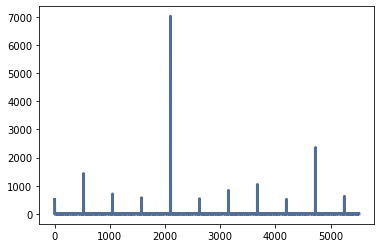

In [107]:
thinkdsp.SquareSignal(2100).make_wave().make_spectrum().plot()


Como se puede observar, los graficos son iguales, lo que significa que la señal tiene una frequencia de 2100Hz.
Para evitar el aliasing, utilizamos filtroe para quitar las frequencias que ocurren debido al aliasing.

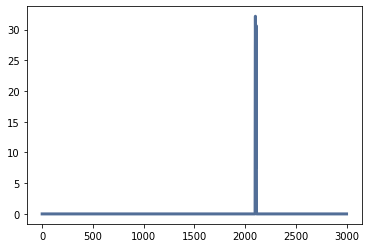

In [133]:
spectrum.high_pass(2000)
spectrum.low_pass(2110)
spectrum.plot(high=3000)


En el grafico anterior, se puede observar la señal sin aliasing, ya que al ser cuadrada la siguiente pendiente, seria a los 6300Hz por lo que queda fuera del grafico.

2.La señal “desconocida.wav” contiene una señal desconocida. A partir de análisis temporales y de espectrograma, describa el tipo de señal encontrada (forma de onda, variación con el tiempo, etc.)

Solucion:

Primero, cargamos la señal 

In [120]:
wave = thinkdsp.read_wave('desconocida.wav')
wave.normalize()
wave.make_audio()


Luego, generamos espectrogramas con distintos largos de segmento, para poder visualizar que ocurre en esta señal

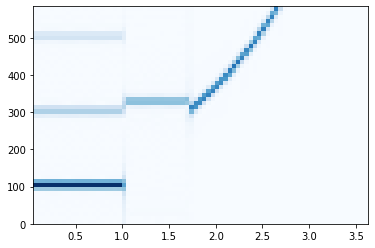

In [126]:
spectrogram = wave.make_spectrogram(1000)
spectrogram.plot(high=600)

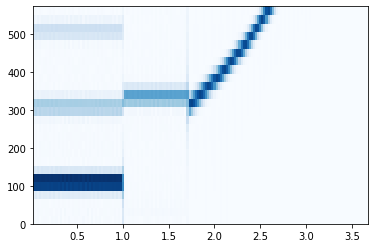

In [129]:
spectrogram = wave.make_spectrogram(500)
spectrogram.plot(high=600)

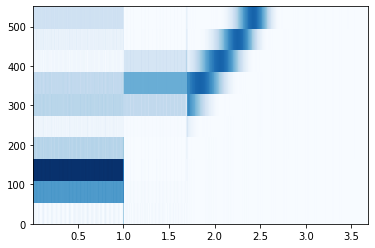

In [123]:
spectrogram = wave.make_spectrogram(200)
spectrogram.plot(high=600)

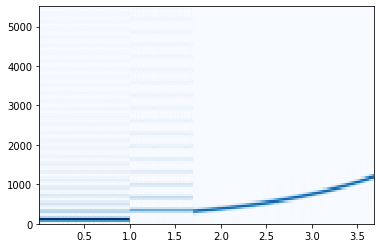

In [127]:
spectrogram = wave.make_spectrogram(200)
spectrogram.plot()

En los espectrograma se puede observar como la señal va cambiando con el tiempo. 
Esta tiene hasta el primer segundo, una frequencia fundamental de alrededor de 150Hz, siendo posiblemente una señal del tipo cuadrada o de diente de sierra.
Desde 1 a 2 segundos, tiene una frecuencia alrededor de 350Hz, siendo tambien una señal del tipo cuadrada o diente de sierra.
Finalmente desde los 2 segundos hasta el final, crece en forma exponencial, parece ser un ExpoChirp.

3.La señal “incognita.wav” contiene una señal recibida desde el espacio exterior. Se sospecha que es una señal muy débil cubierta de ruido, y que la señal solo puede ser triangular de 1000Hz o 2000Hz, diente de sierra de 1500Hz o cosenoidal de 500Hz. ¿Es cierto? Si lo es, ¿qué señal está enmascarada?

Solucion:

Como en los anteriores, primero se carga la señal:

In [113]:
wave = thinkdsp.read_wave('incognita.wav')
wave.normalize()
wave.make_audio()

Veamos el grafico de esta señal

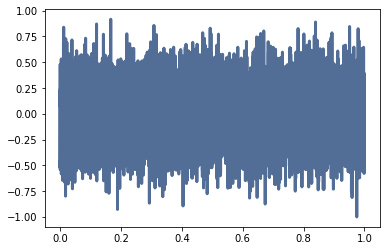

In [114]:
wave.plot()

No se puede distinguir mucho, analizemos el espectro de la señal

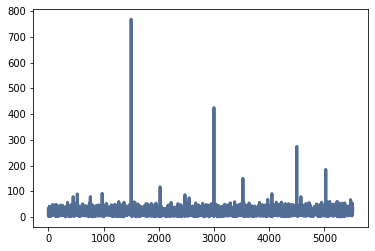

In [115]:
spectrum = wave.make_spectrum()
spectrum.plot()

En el espectro se puede observar como hay tanto la señal como el ruido (lo que esta abajo). Del espectro, se puede observar que la señal tiene aliasing, se puede observar que tiene componentes seguidas, por lo que no es triangular y tiene una frecuencia de alrededor de 1500Hz.
Por los datos anteriores, podemos decir que es una señal de diente de sierra (tiene todas las armonicas) y tiene una frecuencia de 1500Hz, siendo la señal diente de sierra la unica que tiene esta la unica que tiene esta frecuencia.